<a href="https://colab.research.google.com/github/akriti404/Deep-Learning-Lab/blob/main/lab11.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Executing on device: cuda
Epoch   1/200 | Training MSE Loss: 0.214712
Epoch  40/200 | Training MSE Loss: 0.025077
Epoch  80/200 | Training MSE Loss: 0.014285
Epoch 120/200 | Training MSE Loss: 0.022430
Epoch 160/200 | Training MSE Loss: 0.010531
Epoch 200/200 | Training MSE Loss: 0.005386


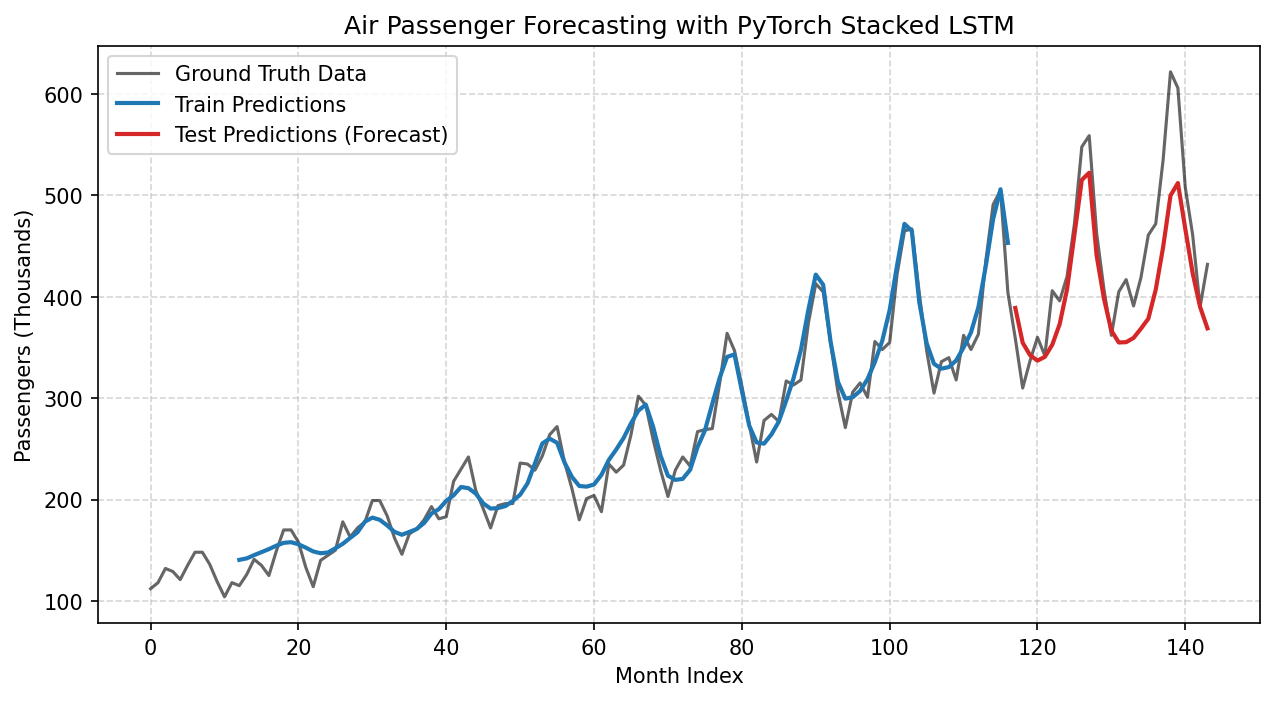

In [2]:
#LSTM
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from sklearn.preprocessing import MinMaxScaler
torch.manual_seed(42)
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv"
df = pd.read_csv(url)

data = df['Passengers'].values.astype(np.float32).reshape(-1, 1)

scaler = MinMaxScaler(feature_range=(-1, 1))
data_normalized = scaler.fit_transform(data)
#prepare data
def create_sequences(data, seq_length):
    xs, ys = [], []
    for i in range(len(data) - seq_length):
        x = data[i : i + seq_length]
        y = data[i + seq_length]
        xs.append(x)
        ys.append(y)
    return torch.tensor(np.array(xs)), torch.tensor(np.array(ys))

SEQ_LENGTH = 12  # Look back 12 months to predict the 13th month
X, y = create_sequences(data_normalized, SEQ_LENGTH)

train_size = int(len(X) * 0.8)
X_train, y_train = X[:train_size], y[:train_size]
X_test, y_test = X[train_size:], y[train_size:]

class AirPassengerLSTM(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=2, output_size=1):
        super(AirPassengerLSTM, self).__init__()

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=0.2
        )
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        # lstm_out shape: (batch_size, sequence_length, hidden_size)
        lstm_out, (h_n, c_n) = self.lstm(x)

        last_step_out = lstm_out[:, -1, :]

        prediction = self.fc(last_step_out)
        return prediction

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Executing on device: {device}")

model = AirPassengerLSTM(input_size=1, hidden_size=64, num_layers=2, output_size=1).to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.005)

X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)

epochs = 200
model.train()
for epoch in range(1, epochs + 1):
    optimizer.zero_grad()
    y_pred = model(X_train)
    loss = criterion(y_pred, y_train)
    loss.backward()
    optimizer.step()

    if epoch % 40 == 0 or epoch == 1:
        print(f"Epoch {epoch:3d}/{epochs} | Training MSE Loss: {loss.item():.6f}")

model.eval()
with torch.no_grad():
    train_preds = model(X_train).cpu().numpy()
    test_preds = model(X_test).cpu().numpy()

train_preds_orig = scaler.inverse_transform(train_preds)
test_preds_orig = scaler.inverse_transform(test_preds)
actual_orig = scaler.inverse_transform(data_normalized)

train_plot = np.empty_like(actual_orig) * np.nan
train_plot[SEQ_LENGTH : train_size + SEQ_LENGTH] = train_preds_orig

test_plot = np.empty_like(actual_orig) * np.nan
test_plot[train_size + SEQ_LENGTH :] = test_preds_orig

plt.figure(figsize=(10, 5), dpi=150)
plt.plot(actual_orig, label="Ground Truth Data", color="black", alpha=0.6)
plt.plot(train_plot, label="Train Predictions", color="tab:blue", linewidth=2)
plt.plot(test_plot, label="Test Predictions (Forecast)", color="tab:red", linewidth=2)
plt.title("Air Passenger Forecasting with PyTorch Stacked LSTM")
plt.xlabel("Month Index")
plt.ylabel("Passengers (Thousands)")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

=== Performance Metric Comparison ===
    Metric / Feature   LSTM    GRU
Trainable Parameters  50497  37889
   Training Time (s) 0.7119 0.8369
           Test RMSE  70.79  42.36
            Test MAE  58.88  34.53


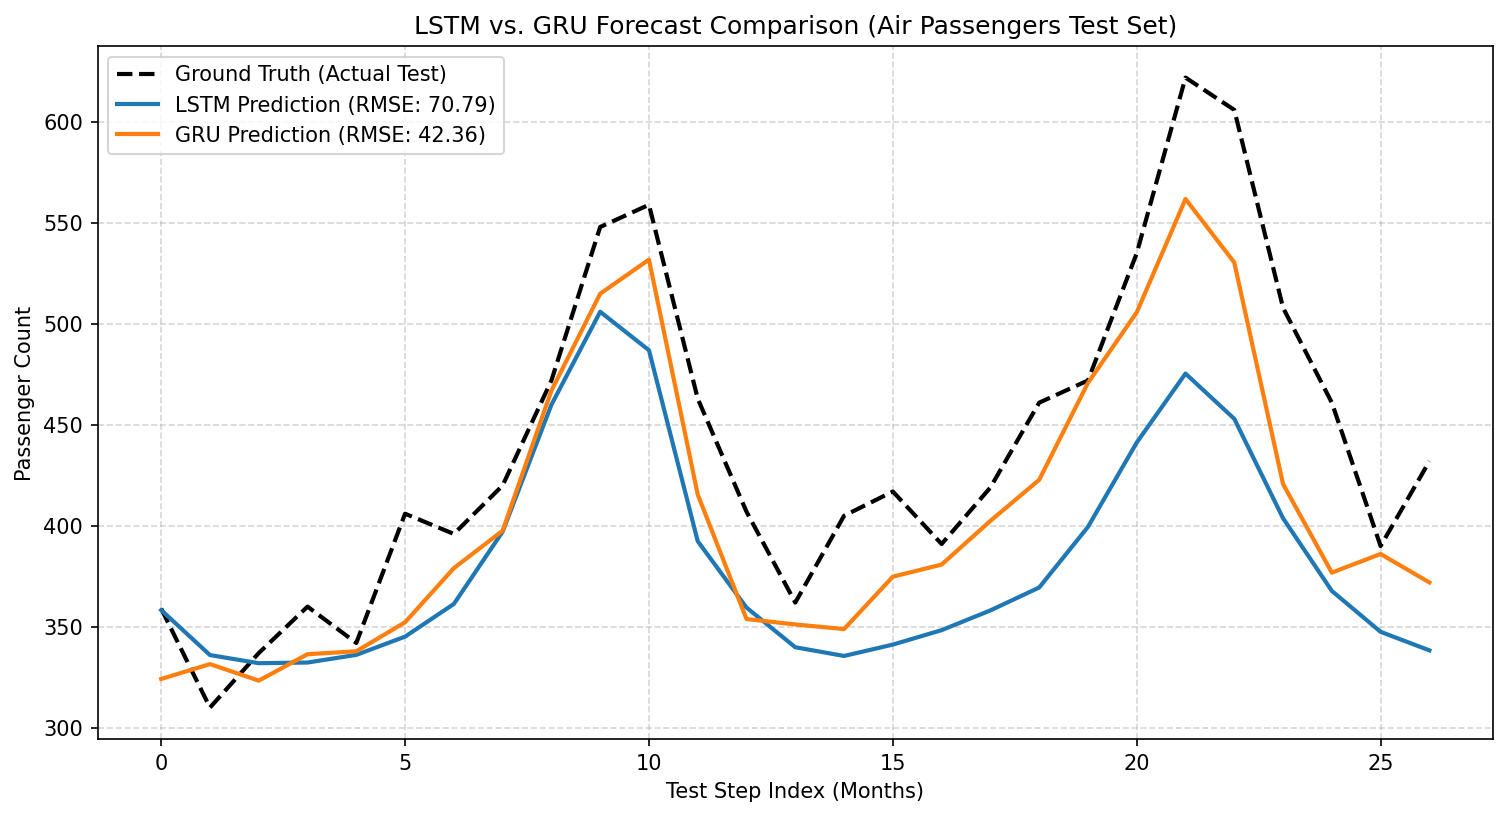

In [3]:
#LSTM and GRU
import numpy as np
import pandas as pd
import time
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

torch.manual_seed(42)

url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv"
df = pd.read_csv(url)
data = df['Passengers'].values.astype(np.float32).reshape(-1, 1)

scaler = MinMaxScaler(feature_range=(-1, 1))
data_norm = scaler.fit_transform(data)

def create_sequences(data, seq_len=12):
    xs, ys = [], []
    for i in range(len(data) - seq_len):
        xs.append(data[i : i + seq_len])
        ys.append(data[i + seq_len])
    return torch.tensor(np.array(xs)), torch.tensor(np.array(ys))

SEQ_LEN = 12
X, y = create_sequences(data_norm, SEQ_LEN)
train_size = int(len(X) * 0.8)

X_train, y_train = X[:train_size], y[:train_size]
X_test, y_test = X[train_size:], y[train_size:]

class UniversalRecurrentModel(nn.Module):
    def __init__(self, cell_type="LSTM", input_size=1, hidden_size=64, num_layers=2):
        super(UniversalRecurrentModel, self).__init__()
        self.cell_type = cell_type

        if cell_type == "LSTM":
            self.rnn = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True, dropout=0.2)
        elif cell_type == "GRU":
            self.rnn = nn.GRU(input_size, hidden_size, num_layers, batch_first=True, dropout=0.2)

        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.rnn(x)
        prediction = self.fc(out[:, -1, :])
        return prediction

def train_and_evaluate(cell_type, epochs=250, lr=0.005):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = UniversalRecurrentModel(cell_type=cell_type).to(device)
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    x_tr, y_tr = X_train.to(device), y_train.to(device)
    x_te, y_te = X_test.to(device), y_test.to(device)

    model.train()
    start_time = time.time()
    for epoch in range(epochs):
        optimizer.zero_grad()
        preds = model(x_tr)
        loss = criterion(preds, y_tr)
        loss.backward()
        optimizer.step()
    training_time = time.time() - start_time

    # Evaluation
    model.eval()
    with torch.no_grad():
        test_preds = model(x_te).cpu().numpy()


    test_preds_actual = scaler.inverse_transform(test_preds)
    y_test_actual = scaler.inverse_transform(y_te.cpu().numpy())

    rmse = np.sqrt(mean_squared_error(y_test_actual, test_preds_actual))
    mae = mean_absolute_error(y_test_actual, test_preds_actual)

    param_count = sum(p.numel() for p in model.parameters() if p.requires_grad)

    return {
        "model": model,
        "preds": test_preds_actual,
        "rmse": rmse,
        "mae": mae,
        "time": training_time,
        "params": param_count,
        "y_test": y_test_actual
    }
# Run LSTM and GRU
lstm_results = train_and_evaluate("LSTM")
gru_results = train_and_evaluate("GRU")
#  Metrics Comparison
metrics_df = pd.DataFrame({
    "Metric / Feature": ["Trainable Parameters", "Training Time (s)", "Test RMSE", "Test MAE"],
    "LSTM": [lstm_results["params"], f"{lstm_results['time']:.4f}", f"{lstm_results['rmse']:.2f}", f"{lstm_results['mae']:.2f}"],
    "GRU": [gru_results["params"], f"{gru_results['time']:.4f}", f"{gru_results['rmse']:.2f}", f"{gru_results['mae']:.2f}"]
})

print("=== Performance Metric Comparison ===")
print(metrics_df.to_string(index=False))

plt.figure(figsize=(12, 6), dpi=150)
plt.plot(lstm_results["y_test"], label="Ground Truth (Actual Test)", color="black", linewidth=2, linestyle="--")
plt.plot(lstm_results["preds"], label=f"LSTM Prediction (RMSE: {lstm_results['rmse']:.2f})", color="tab:blue", linewidth=2)
plt.plot(gru_results["preds"], label=f"GRU Prediction (RMSE: {gru_results['rmse']:.2f})", color="tab:orange", linewidth=2)
plt.title("LSTM vs. GRU Forecast Comparison (Air Passengers Test Set)")
plt.xlabel("Test Step Index (Months)")
plt.ylabel("Passenger Count")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()